In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {device}')

Using Device: cuda


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/fashion-mnist_train.csv')
df.shape

(60000, 785)

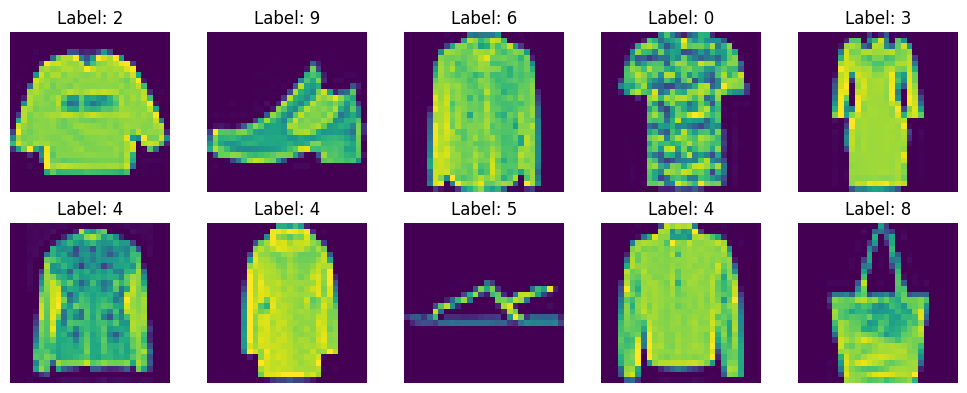

In [ ]:
import matplotlib.pyplot as plt

labels = df['label'].values
pixels = df.drop('label', axis=1).values

# Plot first 10 images
plt.figure(figsize=(10, 4))

for i in range(10):
    image = pixels[i].reshape(28, 28)  # reshape to 28x28

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns=['label'])
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28) # (batchsize,channel,height,width)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

/tmp/ipython-input-998121318.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28) # (batchsize,channel,height,width)
/tmp/ipython-input-998121318.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.long)


In [ ]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32, pin_memory=True)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=32, pin_memory=True)

In [ ]:
# train_loader = DataLoader(train_dataset, shuffle=True, batch_size=64, pin_memory=True)
# test_loader = DataLoader(test_dataset, shuffle=True, batch_size=64, pin_memory=True)

In [ ]:

class MyNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding='same'),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(64, 10),
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)

    return x

In [ ]:
# set learning rate and epochs
epochs = 100
learning_rate = 0.1

In [ ]:
model = MyNN(1)
model = model.to(device)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-5)

In [ ]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move the data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = loss_function(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.6735730470617612
Epoch: 2 , Loss: 0.44785930260519186
Epoch: 3 , Loss: 0.37561158125599226
Epoch: 4 , Loss: 0.3336082821289698
Epoch: 5 , Loss: 0.3045066682423154
Epoch: 6 , Loss: 0.2829828691110015
Epoch: 7 , Loss: 0.2663145790261527
Epoch: 8 , Loss: 0.2535053513223926
Epoch: 9 , Loss: 0.24014891754587492
Epoch: 10 , Loss: 0.22699957009280722
Epoch: 11 , Loss: 0.21512577305485805
Epoch: 12 , Loss: 0.20916141401727995
Epoch: 13 , Loss: 0.19508006696589292
Epoch: 14 , Loss: 0.18858202733285725
Epoch: 15 , Loss: 0.18050124580288926
Epoch: 16 , Loss: 0.17415058116304377
Epoch: 17 , Loss: 0.17093761943420396
Epoch: 18 , Loss: 0.15782878338421386
Epoch: 19 , Loss: 0.15744448702782393
Epoch: 20 , Loss: 0.14972761571438362
Epoch: 21 , Loss: 0.14646788293557864
Epoch: 22 , Loss: 0.1430396427537004
Epoch: 23 , Loss: 0.13853856574821596
Epoch: 24 , Loss: 0.1278456339597081
Epoch: 25 , Loss: 0.12673253008032528
Epoch: 26 , Loss: 0.12356969283008948
Epoch: 27 , Loss: 0.118167045

In [ ]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move the data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.92175


In [ ]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move the data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.9985208333333333


In [ ]:

# # objective function
# def objective(trial):
#   # next hyperparameters values for search space
#   num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 5)
#   neurons_per_layer = trial.suggest_int('neurons_per_layer', 8, 128, step=8)
#   epochs = trial.suggest_int('epochs', 10,50, step=10)
#   learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
#   dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
#   batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
#   optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
#   weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

#   train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size, pin_memory=True)
#   test_loader = DataLoader(test_dataset, shuffle=True, batch_size=batch_size, pin_memory=True)

#   # model init
#   input_dim = 784
#   output_dim = 10

#   model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
#   model.to(device)
#   # params init


#   #optimizers selection
#   loss_function = nn.CrossEntropyLoss()
#   optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
#   if optimizer_name == 'Adam':
#     torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
#   elif optimizer_name == 'RMSprop':
#     torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
#   else:
#     torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)


#   # training loop
#   # training loop

#   for epoch in range(epochs):

#     for batch_features, batch_labels in train_loader:

#       # move the data to gpu
#       batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

#       # forward pass
#       outputs = model(batch_features)

#       # calculate loss
#       loss = loss_function(outputs, batch_labels)

#       # back pass
#       optimizer.zero_grad()
#       loss.backward()

#       # update grads
#       optimizer.step()


#   # evaluation loop
#   model.eval()
#   # evaluation code
#   total = 0
#   correct = 0

#   with torch.no_grad():

#     for batch_features, batch_labels in test_loader:

#       # move the data to gpu
#       batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

#       outputs = model(batch_features)

#       _, predicted = torch.max(outputs, 1)

#       total = total + batch_labels.shape[0]

#       correct = correct + (predicted == batch_labels).sum().item()

#     accuracy = correct/total


#   return accuracy

In [ ]:
!pip install optuna

In [ ]:
import optuna
study = optuna.create_study(direction='maximize')

[I 2026-02-15 20:08:47,637] A new study created in memory with name: no-name-cecd2929-e6ae-41dd-ba7e-f53b71949634


In [ ]:
study.optimize(objective, n_trials=10)

[I 2026-02-15 20:11:06,331] Trial 0 finished with value: 0.8581666666666666 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 24, 'epochs': 50, 'learning_rate': 0.06407473429143654, 'dropout_rate': 0.2, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0007988931040907692}. Best is trial 0 with value: 0.8581666666666666.
[I 2026-02-15 20:13:52,685] Trial 1 finished with value: 0.8505 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 40, 'epochs': 50, 'learning_rate': 0.025543511953437133, 'dropout_rate': 0.4, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0003221424138728959}. Best is trial 0 with value: 0.8581666666666666.
[I 2026-02-15 20:16:05,694] Trial 2 finished with value: 0.72975 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 96, 'epochs': 40, 'learning_rate': 2.628536697315649e-05, 'dropout_rate': 0.1, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0007372203313923335}. Best is trial 0 with value: 0.858166

In [ ]:
class Model(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128,eps=1e-5),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64,eps=1e-5),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64,10)
    )

  def forward(self, x):
    return self.model(x)


In [ ]:
# set learning rate and epochs
# epochs = 100
# learning_rate = 0.1

In [ ]:
# model = Model(X_train_tensor.shape[1])
# model = model.to(device)

# loss_function = nn.CrossEntropyLoss()

# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
len(train_loader)

In [ ]:
# # training loop

# for epoch in range(epochs):

#   total_epoch_loss = 0

#   for batch_features, batch_labels in train_loader:

#     # move the data to gpu
#     batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

#     # forward pass
#     outputs = model(batch_features)

#     # calculate loss
#     loss = loss_function(outputs, batch_labels)

#     # back pass
#     optimizer.zero_grad()
#     loss.backward()

#     # update grads
#     optimizer.step()

#     total_epoch_loss = total_epoch_loss + loss.item()

#   avg_loss = total_epoch_loss/len(train_loader)
#   print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


In [ ]:
# set model to eval mode
# model.eval()

In [ ]:
# # evaluation code
# total = 0
# correct = 0

# with torch.no_grad():

#   for batch_features, batch_labels in test_loader:

#     # move the data to gpu
#     batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

#     outputs = model(batch_features)

#     _, predicted = torch.max(outputs, 1)

#     total = total + batch_labels.shape[0]

#     correct = correct + (predicted == batch_labels).sum().item()

# print(correct/total)


In [ ]:
# # evaluation code
# total = 0
# correct = 0

# with torch.no_grad():

#   for batch_features, batch_labels in train_loader:

#     # move the data to gpu
#     batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

#     outputs = model(batch_features)

#     _, predicted = torch.max(outputs, 1)

#     total = total + batch_labels.shape[0]

#     correct = correct + (predicted == batch_labels).sum().item()

# print(correct/total)
